In [1]:
import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Load CSV
df = pd.read_csv("Data_Entry_2017_v2020.csv")

df['Finding Labels'] = df['Finding Labels'].str.split('|')
desiredClasses = ['No Finding', 'Pneumothorax', 'Cardiomegaly', 'Mass', 'Nodule']
# desiredClasses = ['Pneumothorax', 'Cardiomegaly', 'Mass', 'Nodule']
desiredSet = set(desiredClasses)

df = df[df['Finding Labels'].apply(lambda x: sum(label in desiredClasses for label in x) == 1)] #Gets lines where only one category in the list is present
df['Finding Labels'] = df['Finding Labels'].apply(lambda x: list(set(x) & desiredSet)[0]) #Makes the ´Finding Labels´ column only have this category
df = df.drop_duplicates(subset='Patient ID') #Keeps only one register per patient
np.unique(df['Finding Labels'])

#Count classes, get the number of lines of the min appearing class
maxN = df['Finding Labels'].value_counts().min()

#Random sampling of classes, getting max lines possible
df = df.groupby('Finding Labels', group_keys=False).sample(n=maxN, random_state=23062025)
df


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
9653,00002506_000.png,Cardiomegaly,0,2506,19,M,PA,2500,2048,0.171,0.171
110237,00030012_000.png,Cardiomegaly,0,30012,58,M,AP,3056,2544,0.139,0.139
525,00000123_000.png,Cardiomegaly,0,123,50,M,PA,2048,2500,0.171,0.171
9332,00002435_006.png,Cardiomegaly,0,2435,40,F,AP,2500,2048,0.171,0.171
100074,00026522_000.png,Cardiomegaly,0,26522,43,F,PA,2992,2991,0.143,0.143
...,...,...,...,...,...,...,...,...,...,...,...
105848,00028501_000.png,Pneumothorax,0,28501,61,M,AP,3056,2544,0.139,0.139
82091,00020200_002.png,Pneumothorax,1,20200,53,F,AP,3056,2544,0.139,0.139
101489,00026967_005.png,Pneumothorax,5,26967,53,F,AP,3056,2544,0.139,0.139
86624,00021374_001.png,Pneumothorax,1,21374,80,M,PA,2992,2991,0.143,0.143


In [2]:
# import tarfile
# from pathlib import Path

# tar_files = [
#     'tars/images_001.tar.gz',
#     'tars/images_002.tar.gz',
#     'tars/images_003.tar.gz',
#     'tars/images_004.tar.gz',
#     'tars/images_005.tar.gz',
#     'tars/images_006.tar.gz',
#     'tars/images_007.tar.gz',
#     'tars/images_008.tar.gz',
#     'tars/images_009.tar.gz',
#     'tars/images_010.tar.gz',
#     'tars/images_011.tar.gz',
#     'tars/images_012.tar.gz',
# ]  

# # Setup output directory
# output_dir = Path('./extracted_images') # final output will be /extracted_images/images
# output_dir.mkdir(parents=True, exist_ok=True)

# image_index_set = set(df['Image Index'])
# df['Recovered_Image'] = 0

# # Get only desired files directly from tar.gz so we dont blow our storage
# for tar_path in tar_files:
#     with tarfile.open(tar_path, 'r:gz') as tar:
#         haha = tar.getmembers()
#         for member in tar.getmembers():
#             filename = Path(member.name).name
#             filePath = output_dir / 'images' / filename
#             if filePath.exists():
#                 df.loc[df['Image Index'] == filename, 'Recovered_Image'] = 1 #mark that image was found
#                 continue
#             if filename in image_index_set:
#                 tar.extract(member, path=output_dir)
#                 df.loc[df['Image Index'] == filename, 'Recovered_Image'] = 1 #mark that image was found



# #Drop all df entries that are not in the extracted_folder
# df.drop(df[df['Recovered_Image'] == 0].index, inplace=True)
# df.drop(columns=['Recovered_Image'], inplace=True)
# df

In [3]:
#Train test split, while preserving the balance of the conditions
train_patients, val_patients = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Finding Labels'],
    random_state=42
)

print(f"Train images: {len(train_patients)}, Val images: {len(val_patients)}")
print(f"Train patients: {len(train_patients)}, Val patients: {len(val_patients)}\n")

print("Train class distribution:")
print(train_patients['Finding Labels'].value_counts())

print("\nValidation class distribution:")
print(val_patients['Finding Labels'].value_counts())

Train images: 1204, Val images: 301
Train patients: 1204, Val patients: 301

Train class distribution:
Finding Labels
Mass            241
Cardiomegaly    241
No Finding      241
Pneumothorax    241
Nodule          240
Name: count, dtype: int64

Validation class distribution:
Finding Labels
Nodule          61
Mass            60
No Finding      60
Cardiomegaly    60
Pneumothorax    60
Name: count, dtype: int64


# Starting to make the model

In [4]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.class_names = sorted(self.df['Finding Labels'].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(self.class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'Image Index']
        label_str = self.df.loc[idx, 'Finding Labels']
        label = self.label_to_idx[label_str]  
        img_path = os.path.join(self.img_dir, img_name)

        # image = Image.open(img_path).convert('L')  # grayscale
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)
    
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = ChestXrayDataset(train_patients, 'extracted_images/images', transform=transform)
val_dataset = ChestXrayDataset(val_patients, 'extracted_images/images', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [5]:
import torchvision.models as models
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

resnet = models.resnet18(pretrained=True)
for param in resnet.parameters():
    param.requires_grad = False  # freeze feature extractor

# Replace classifier
num_classes = len(set(train_patients['Finding Labels']))
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

d:\MC906-DiagXray\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\MC906-DiagXray\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

num_epochs = 15
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    resnet.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss / len(train_loader))

    # Validation
    resnet.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    correctt = 0
    running_loss = 0.0

    val_losses.append(val_loss / len(val_loader))
    # preds = (outputs > 0.5).float()
    # correctt += (preds == labels).sum().item()
    # epoch_acc = correctt / labels.size(0)
    # print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Accuracy: {epoch_acc*100:.2f}%")
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    

RuntimeError: The size of tensor a (5) must match the size of tensor b (13) at non-singleton dimension 1

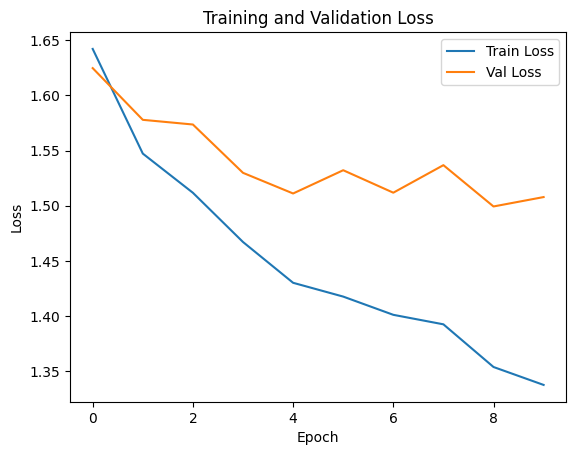

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

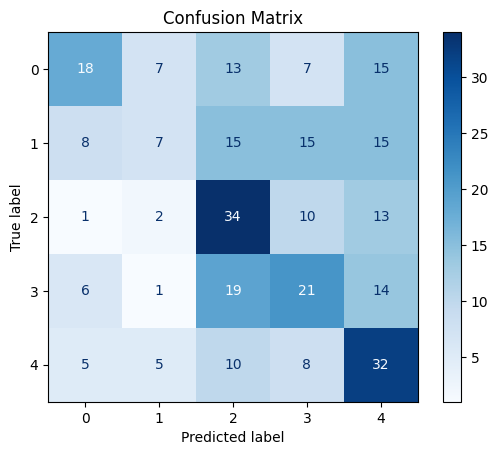

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

resnet.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = resnet(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()